## Root Cause Analysis - Exp2

* Goals
  * Root Cause Analysis on individual RAG results --> 2 RAGs results comparison
  * Provide actionable suggestions
* About Exp2
  * Build Langgraph Agent System for Root Cause Analysis

In [1]:
%load_ext autoreload
%autoreload 2

import os
from sqlalchemy import make_url
import pandas as pd

from utils_root_cause import *

from langchain_groq import ChatGroq
from typing import TypedDict, Literal, Optional
from langgraph.graph import StateGraph, START, END
import json

import warnings
warnings.filterwarnings('ignore')


exp_llm = ChatGroq(
    groq_api_key=os.environ["GROQ_TOKEN"],
    model_name="openai/gpt-oss-20b", 
    temperature=0.78
)

DATABASE_URL_PUBLIC = os.getenv("DATABASE_URL_PUBLIC_RAG_DR")
DATABASE_URL = DATABASE_URL_PUBLIC.replace("postgres://", "postgresql://")
db_url = make_url(DATABASE_URL)

In [2]:
auto_eval_output = get_auto_eval_output(db_url)
print(auto_eval_output.shape)

auto_eval_output.head(n=2)

left_auto_eval_output = auto_eval_output.iloc[0:30]
right_auto_eval_output = auto_eval_output.iloc[30:60]
print(left_auto_eval_output.shape, right_auto_eval_output.shape)

(60, 16)
(30, 16) (30, 16)


In [3]:
# =========================
# State Schema
# =========================
class RCAState(TypedDict):
    r_idx: int
    query: str
    referenced_content: str
    retrieved_content: str
    retrieval_quality_score: int
    rq_reasoning: str

    embedding_model: str
    top_n_retrieval: int
    semantic_weight: float
    answer_gen_llm: str

    referenced_answer: str
    ai_answer: str
    answer_quality_score: int
    aq_reasoning: str

    new_retrieval_quality_score: int   
    new_answer_quality_score: int
    query_quality: str     
    root_cause_analysis: list[dict[str, str]]  # dict key is root cause, value is improvement suggestions
    re_eval_lst: set[int]  # store the index of records that should be re-evaluated after updates

    referenced_answer_context_alignment: Optional[int]  # indicate whether referenced answer has critical info alignede with the referenced content
    referenced_answer_context_alignment_reason: Optional[str]
    ai_answer_context_alignment: Optional[int]  # indicate whether AI answer has critical info alignede with the referenced content
    ai_answer_context_alignment_reason: Optional[str]

In [4]:
# =========================
# AI-as-Judge Reviewer
# =========================
async def review_evaluation_output(state: RCAState):
    rq_score_after_review = await review_sr_async(exp_llm, state['rq_reasoning'])
    aq_score_after_review = await review_sr_async(exp_llm, state['aq_reasoning'])

    root_cause_analysis = []
    if rq_score_after_review != state['retrieval_quality_score']:
        root_cause_analysis.append({'auto eval score issue': f'score vs reasoning mismatch, \
                                    changed retrieval_quality_score from {state["retrieval_quality_score"]} to {rq_score_after_review}'})
    if aq_score_after_review != state['answer_quality_score']:
        root_cause_analysis.append({'auto eval score issue': f'score vs reasoning mismatch, \
                                    changed answer_quality_score from {state["answer_quality_score"]} to {aq_score_after_review}'})

    return {
        "new_retrieval_quality_score": rq_score_after_review,
        "new_answer_quality_score": aq_score_after_review,
        "root_cause_analysis": root_cause_analysis
    }


# =========================
# Reference Reviewer
# =========================
async def review_referenced_data(state: RCAState):
    rq_score = state['new_retrieval_quality_score']
    aq_score = state['new_answer_quality_score']
    root_cause_analysis = state['root_cause_analysis']
    re_eval_lst = set()

    rc_alignment_score, rc_alignment_reason = None, None
    ac_alignment_score, ac_alignment_reason = None, None

    if rq_score == -1:
        root_cause_analysis.append({'Please review referenced content':
                                            'referenced content is much less relevant to the query than retrieved content'})
        re_eval_lst.add(state['r_idx'])
    if aq_score == -1:
        root_cause_analysis.append({"Please review referenced answer":
                                            "referenced answer is much less relevant to the query than AI's answer"})
        re_eval_lst.add(state['r_idx'])

    if rq_score >= 2 and aq_score in [0, 1]:  # good retrieval, bad answer
        referenced_answer_context_alignment = await review_ta_async(exp_llm,state['query'],
                                                                    state['referenced_answer'], state['referenced_content'])
        rc_alignment_score = referenced_answer_context_alignment.score
        rc_alignment_reason = referenced_answer_context_alignment.reasoning
        if rc_alignment_score == 0:
            root_cause_analysis.append({'Please review referenced answer':
                                        'referenced answer has critical information misaligned with the referenced content'})
            re_eval_lst.add(state['r_idx'])
            
    if rq_score in [0, 1] and aq_score >= 2:  # good answer, bad retrieval
        ai_answer_context_alignment = await review_ta_async(exp_llm,state['query'],
                                                                    state['ai_answer'], state['referenced_content'])
        ac_alignment_score = ai_answer_context_alignment.score
        ac_alignment_reason = ai_answer_context_alignment.reasoning
        if ac_alignment_score == 0:
            root_cause_analysis.append({"Please review referenced content':\
                                        AI's answer got a high score but retrieval score is low, \
                                        please check whether need to add or merge retrieved content into the referenced content."})
            re_eval_lst.add(state['r_idx'])

    return {
        "referenced_answer_context_alignment": rc_alignment_score,
        "referenced_answer_context_alignment_reason": rc_alignment_reason,
        "ai_answer_context_alignment": ac_alignment_score,
        "ai_answer_context_alignment_reason": ac_alignment_reason,
        "root_cause_analysis": root_cause_analysis,
        "re_eval_lst": re_eval_lst
    }


# =========================
# Query Quality Reviewer
# =========================
async def review_query_quality(state: RCAState):
    query_quality = await review_query_quality_async(exp_llm, state['query'])
    root_cause_analysis = state['root_cause_analysis']

    if query_quality == 'ambiguous':
        query_variants = await expand_query_async(exp_llm, state['query'])
        root_cause_analysis.append({'Please review query quality': query_variants})

    return {
        "query_quality": query_quality,
        "root_cause_analysis": root_cause_analysis
    }

In [5]:
workflow = StateGraph(RCAState)

workflow.add_node("Evaluation Reviewer", review_evaluation_output)
workflow.add_node("Reference Reviewer", review_referenced_data)
workflow.add_node("Query Quality Reviewer", review_query_quality)

workflow.add_edge(START, "Evaluation Reviewer")
workflow.add_edge("Evaluation Reviewer", "Reference Reviewer")
workflow.add_edge("Reference Reviewer", "Query Quality Reviewer")
workflow.add_edge("Query Quality Reviewer", END)

graph = workflow.compile()

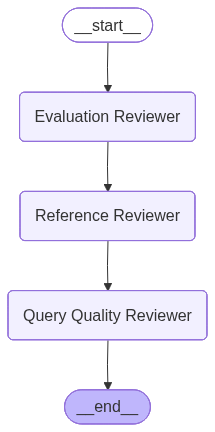

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

In [6]:
async def run_rca_on_all(df, max_concurrent=2):
    sem = asyncio.Semaphore(max_concurrent)
    async def throttled_invoke(state):
        async with sem:
            return await graph.ainvoke(state)

    states = [
        {
            "r_idx": idx,
            "query": row["query"],
            "referenced_content": row["context"],
            "retrieved_content": row["retrieved_content"],
            "retrieval_quality_score": int(row["retrieval_quality_score"]),
            "rq_reasoning": row["rq_reasoning"],
            "referenced_answer": row["referenced_answer"],
            "ai_answer": row["ai_answer"],
            "answer_quality_score": int(row["answer_quality_score"]),
            "aq_reasoning": row["aq_reasoning"],
            "embedding_model": row["embedding_model"],
            "top_n_retrieval": row["top_n_retrieval"],
            "semantic_weight": row["semantic_weight"],
            "answer_gen_llm": row["answer_gen_llm"]
        }
        for idx, row in df.iterrows()
    ]
    return await asyncio.gather(*[throttled_invoke(s) for s in states])

left_rca_results, right_rca_results = await asyncio.gather(
    run_rca_on_all(left_auto_eval_output),
    run_rca_on_all(right_auto_eval_output)
)

In [7]:
left_rca_results_df = pd.DataFrame(left_rca_results)
left_diff_df = left_rca_results_df[(left_rca_results_df["retrieval_quality_score"] != left_rca_results_df["new_retrieval_quality_score"]) \
                         | (left_rca_results_df["answer_quality_score"] != left_rca_results_df["new_answer_quality_score"])]
right_rca_results_df = pd.DataFrame(right_rca_results)
right_diff_df = right_rca_results_df[(right_rca_results_df["retrieval_quality_score"] != right_rca_results_df["new_retrieval_quality_score"]) \
                         | (right_rca_results_df["answer_quality_score"] != right_rca_results_df["new_answer_quality_score"])]
display(left_diff_df.shape, right_diff_df.shape)

(4, 23)

(4, 23)

In [8]:
left_re_eval_lst = left_rca_results_df[left_rca_results_df['re_eval_lst'].apply(lambda x: len(x) > 0)]
right_re_eval_lst = right_rca_results_df[right_rca_results_df['re_eval_lst'].apply(lambda x: len(x) > 0)]
print(len(left_re_eval_lst), len(right_re_eval_lst))

for lst in left_re_eval_lst['root_cause_analysis']:
    for elem in lst:
        print(json.dumps(elem, indent=4, ensure_ascii=False, default=json_default))

11 9
{
    "auto eval score issue": "score vs reasoning mismatch,                                     changed retrieval_quality_score from 1 to 2"
}
{
    "Please review referenced answer": "referenced answer is much less relevant to the query than AI's answer"
}
{
    "Please review query quality": [
        "How can one EIN be used for multiple DBA (doing‑business‑as) names?",
        "What is the process for registering multiple business names under a single EIN?",
        "How can I retrieve all business names associated with a specific EIN?"
    ]
}
{
    "Please review referenced answer": "referenced answer is much less relevant to the query than AI's answer"
}
{
    "Please review query quality": [
        "What deductible amount can a small business claim on its taxes?",
        "How is the deductible amount calculated for a small business?",
        "What are the purposes of the deductible amount for small businesses?"
    ]
}
[
    "Please review referenced content':         

In [9]:
async def run_rag_review(agg_df, exp_llm, system_prompt):
    avg_rq_score = agg_df['new_retrieval_quality_score'].mean()
    avg_aq_score = agg_df['new_answer_quality_score'].mean()

    rq_reasons = agg_df['rq_reasoning'].tolist()
    aq_reasons = agg_df['aq_reasoning'].tolist()

    sample_record = agg_df.iloc[0]
    rag_config = f"""
                    - Embedding model: {sample_record['embedding_model']}
                    - Top N retrieval: {sample_record['top_n_retrieval']}
                    * It specifies the number of top relevant documents retrieved to assist answer generation.
                    - Semantic weight: {sample_record['semantic_weight']}
                    * Semantic weight means the percentage of semantic retrieval, 1 - semantic_weight is the percentage of keyword retrieval.
                    - Answer generation LLM: {sample_record['answer_gen_llm']}
                    * The LLM used to generate the answer based on the retrieved content and the query.
                    """

    return await review_rag_system_async(exp_llm, avg_rq_score, rq_reasons,
                                         avg_aq_score, aq_reasons, system_prompt, rag_config)

In [10]:
system_prompt = FINANCIAL_RAG_SYSTEM_PROMPT

left_agg_df = left_rca_results_df[left_rca_results_df['re_eval_lst'].apply(lambda x: len(x) == 0)]
right_agg_df = right_rca_results_df[right_rca_results_df['re_eval_lst'].apply(lambda x: len(x) == 0)]
print(len(left_agg_df), len(right_agg_df))

left_rag_sys_review, right_rag_sys_review = await asyncio.gather(
    run_rag_review(left_agg_df, exp_llm, system_prompt),
    run_rag_review(right_agg_df, exp_llm, system_prompt)
)

print(left_rag_sys_review.root_cause_analysis)
print(left_rag_sys_review.improvement_suggestions)
print()
print(right_rag_sys_review.root_cause_analysis)
print(right_rag_sys_review.improvement_suggestions)

19 21
Answer quality suffers because the single retrieved doc often lacks some key details, the LLM omits them per strict prompt, and the embedding model/semantic weight may miss nuanced info.
- Retrieve top 3–5 documents to cover multiple aspects.
- Switch to a larger, domain‑aware embedding model (e.g., sentence‑transformers/all-mpnet-base-v2).
- Increase semantic weight to 0.7 or 0.8 for better semantic matching.
- Expand prompt to instruct the LLM to enumerate all critical points from retrieved content.
- Add a post‑generation check that flags missing key details and prompts the model to elaborate.
- Use a reranker to ensure relevance while keeping top‑N retrieval low.
- Encourage chain‑of‑thought reasoning to capture nuance.
- Allow the model to say "I don't know" only if no retrieved content covers the query.

Low answer scores stem from retrieving only one document, low semantic weight, and the model omitting key details present in the source.
- Increase Top N retrieval to 3–5 s